# Project 2: Choosing a Model for Predicting on Unseen Data

Before we start, please put your name and CUID in following format

: Firstname LASTNAME, #00000000   //   e.g. Nianyi LI, #12345678

**Your Answer:**   
Keller Brandenburg, #14328920

# General Rules of the Project Submission

Python 3 and [Matplotlib](https://matplotlib.org/) will be used throughout the semseter, so it is important to be familiar with them. It is strongly suggested to go through [Stanford CS231n](http://cs231n.github.io/python-numpy-tutorial/) and [CS228](https://github.com/kuleshov/cs228-material/blob/master/tutorials/python/cs228-python-tutorial.ipynb) for more detailed Python and numpy tutorials if you haven't had used Python before.

In some cells and files you will see code blocks that look like this:

```python
##############################################################################
#                    TODO: Write the equation for a line                     #
##############################################################################
pass
##############################################################################
#                              END OF YOUR CODE                              #
##############################################################################
```

You should replace the `pass` statement with your own code and leave the blocks intact, like this:

```python
##############################################################################
#                    TODO: Write the equation for a line                     #
##############################################################################
y = m * x + b
##############################################################################
#                              END OF YOUR CODE                              #
##############################################################################
```

When completing the notebook, please adhere to the following rules:
- Do not write or modify any code outside of code blocks
- Follow the instruction of the project description carefully
- Run all cells before submitting. <span style="color:red">**You will only get credit for code that has been run!**.</span>

The last point is extremely important and bears repeating:

### We will not re-run your notebook -- <span style="color:red">you will only get credit for cells that have been run</span>

### File name
Your Python program should be named **yourlastname_yourfirstname_P2.ipynb**, then zip it and upload to Canvas

### Package usage
You <span style="color:red">**cannot**</span> use python machine learning package that can have the k-fold validation algorithm as embedded function, for instance, **sklearn** package.

# Project Description

For Project 2 you will create a regression program and choose a model to predict the women’s Olympic 100-meter race record time for year **2024** and **2028**. We will code the year of each race as we did in lecture 2.3.

![caption](https://nianyil.people.clemson.edu/CPSC_4430/P2.jpg)


## Data File

A text file with the data is available on Canvas for the years 1928 through 2008 when the Olympics were held. The first line of the text file indicating there’re **m** lines of data and a **n** number of features (in this case, one). You need to write a code to read data from the file. You **can** use packages, such as **panda**, to load the data.

In [2]:
##############################################################################
#         TODO: Write the code for reading data from file                    #
##############################################################################
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
# import statsmodels.api as sm
import pandas as pd

from google.colab import files
uploaded = files.upload()  #read in file

#Read the data into a dataframe
df = pd.read_csv("/content/W100MTimes.txt", delim_whitespace=True, names=['year', 'time'])
m=df['year'][0]
n=df['time'][0]
df=df.drop([0]).reset_index(drop=True)
df=df.convert_dtypes(float)
##############################################################################
#                              END OF YOUR CODE                              #
##############################################################################

Saving W100MTimes.txt to W100MTimes.txt


## Pick the Best Model

Your project assignment is to compare four different models, linear, quadratic, cubic, fourth, and fifth.

- $h_w(x) = w_0 + w_1x$
- $h_w(x) = w_0 + w_1x + w_2x^2$
- $h_w(x) = w_0 + w_1x + w_2x^2 + w_3x^3$
- $h_w(x) = w_0 + w_1x + w_2x^2 + w_3x^3 + w_4x^4$
- $h_w(x) = w_0 + w_1x + w_2x^2 + w_3x^3 + w_4x^4 + w_5x^5$


In [3]:
##############################################################################
#                 TODO: Define the regression models                         #
##############################################################################
x = np.array(df['year'].astype(float))
y = np.array(df['time'].astype(float))
def getWeights(x,y,n):
    X_poly = np.array([np.power(x, p) for p in range(n+1)]).T
    Xt_X_inv = np.linalg.inv(X_poly.T @ X_poly)
    Xt_y = X_poly.T @ y
    coefs = Xt_X_inv @ Xt_y
    return coefs

from sympy import Symbol, poly
def polynom(p):
    return poly(sum(coef*Symbol('x')**i for i, coef in enumerate(p)))
##############################################################################
#                              END OF YOUR CODE                              #
##############################################################################

Next, you need to use <span style="color:red">**5-fold cross validation**</span> to pick out the best model for the prediction. You should present a chart of the error function $J$, similar to the one in the lecture (see below). You may need to use package like "**tabulate**" to print out the table.

```
                     Linear    Quadratic    Cubic    Fourth
-----------------  --------  -----------  -------  --------
1234                  10.25        24.25    12.25     23.25
5                     10.25        19.25    14.25     23.25
1235                  10.25        15.25    19.25     23.25
4                     10.25        10.25    20.25     23.25
1245                  10.25        24.25    12.25     23.25
3                     10.25        19.25    14.25     23.25
1345                  10.25        24.25    12.25     23.25
2                     10.25        19.25    14.25     23.25
2345                  10.25        24.25    12.25     23.25
1                     10.25        19.25    14.25     23.25
Mean for Training      0            0        0         0
Mean for Testing       0            0        0         0
```

You need to **plot** your training and testing $J$ with respect to the polynomial degree, similar to the one in the lecture.

In [5]:
##############################################################################
#                     TODO: 5-fold cross-validation                         #
##############################################################################
#create folds
xtest = np.array_split(x, 5)
xtrain = []
ytest = np.array_split(y, 5)
ytrain = []
for j in range(5):
    xtrain.append(x.tolist())
    ytrain.append(y.tolist())
    for i in xtest[j]:
        if i in xtrain[j]:
            xtrain[j].remove(i)
    for i in ytest[j]:
        if i in ytrain[j]:
            ytrain[j].remove(i)

#make 5 regressions per fold
regressionList = []
for i in range(5):
    tempList=[]
    for j in range(1,6):
        tempList.append(polynom(getWeights(xtrain[i],ytrain[i],j)))
    regressionList.append(tempList)
#calculate error between data sets and regressions
jTest=[]
for i in range(5):
    tempList=[]
    for j in range(5):
        sse=0
        for k in range(len(xtest[i])):
            sse+=np.square(regressionList[i][j](xtest[i][k]) - ytest[i][k])
        tempList.append(sse/len(xtest[i]))
    jTest.append(tempList)
jTrain=[]
for i in range(5):
    tempList=[]
    for j in range(5):
        sse=0
        for k in range(len(xtrain[i])):
            sse+=np.square(regressionList[i][j](xtrain[i][k]) - ytrain[i][k])
        tempList.append(sse/len(xtrain[i]))
    jTrain.append(tempList)

meanTrain = []
meanTest = []
for i in range(5):
    sumTrain = 0
    sumTest = 0
    for j in range(5):
        sumTrain += jTrain[j][i]
        sumTest += jTest[j][i]
    meanTrain.append(sumTrain/5)
    meanTest.append(sumTest/5)
##############################################################################
#                              END OF YOUR CODE                              #
##############################################################################

In [6]:
##############################################################################
#                     TODO: Print out the table chart                       #
##############################################################################
from tabulate import tabulate
table = [['2345', jTrain[0][0], jTrain[0][1], jTrain[0][2], jTrain[0][3], jTrain[0][4]],
         ['1', jTest[0][0], jTest[0][1], jTest[0][2], jTest[0][3], jTest[0][4]],
         ['1345', jTrain[1][0], jTrain[1][1], jTrain[1][2], jTrain[1][3], jTrain[1][4]],
         ['2', jTest[1][0], jTest[1][1], jTest[1][2], jTest[1][3], jTest[1][4]],
         ['1245', jTrain[2][0], jTrain[2][1], jTrain[2][2], jTrain[2][3], jTrain[2][4]],
         ['3', jTest[2][0], jTest[2][1], jTest[2][2], jTest[2][3], jTest[2][4]],
         ['1235', jTrain[3][0], jTrain[3][1], jTrain[3][2], jTrain[3][3], jTrain[3][4]],
         ['4', jTest[3][0], jTest[3][1], jTest[3][2], jTest[3][3], jTest[3][4]],
         ['1234', jTrain[4][0], jTrain[4][1], jTrain[4][2], jTrain[4][3], jTrain[4][4]],
         ['5', jTest[4][0], jTest[4][1], jTest[4][2], jTest[4][3], jTest[4][4]],
         ["Mean Train", meanTrain[0], meanTrain[1], meanTrain[2], meanTrain[3], meanTrain[4]],
         ["Mean Test", meanTest[0], meanTest[1], meanTest[2], meanTest[3], meanTest[4]]]
headers=[' ', 'Linear', 'Quadratic', 'Cubic', 'Fourth', 'Fifth']
print(tabulate(table, headers, tablefmt='simple'))
##############################################################################
#                              END OF YOUR CODE                              #
##############################################################################

               Linear    Quadratic      Cubic     Fourth        Fifth
----------  ---------  -----------  ---------  ---------  -----------
2345        0.0328357    0.0255338  0.0253479  0.0248284    0.0196647
1           0.199419     0.115478   0.305187   0.844881   162.88
1345        0.0399015    0.0172394  0.0171573  0.0171082    0.0155262
2           0.04373      0.0390513  0.0415366  0.0417752    0.035114
1245        0.050414     0.0388677  0.0364709  0.0363629    0.0197977
3           0.0313884    0.0073148  0.0104592  0.0108926    0.0722202
1235        0.0460154    0.0327898  0.0326936  0.0314057    0.0239151
4           0.0643973    0.0516594  0.0572937  0.0854885    0.0851933
1234        0.0383639    0.0354708  0.0349359  0.0320274    0.03099
5           0.176176     0.0677583  0.0351024  0.478374     0.0335638
Mean Train  0.0415061    0.0299803  0.0293211  0.0283465    0.0219787
Mean Test   0.103022     0.0562524  0.0899157  0.292282    32.6213


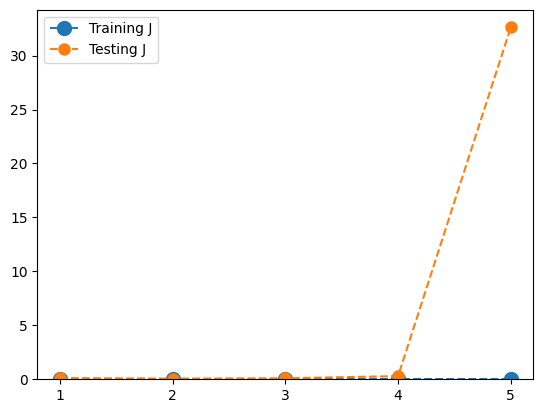

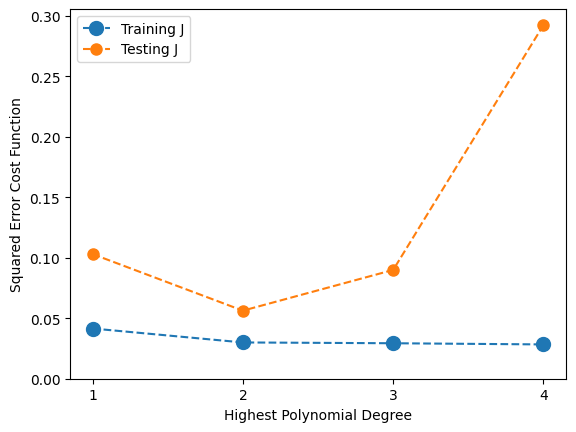

In [7]:
##############################################################################
#                     TODO: Plot the J curve                                 #
##############################################################################
f, ax = plt.subplots(1)
f2, ax2 = plt.subplots(1) #for use later in setting the y axis minimum to 0

#full graph
ax.plot(['1','2','3','4','5'], meanTrain, 'o', linestyle='--',label='Training J', markersize=10)
ax.plot(['1','2','3','4','5'], meanTest, 'o', linestyle='--',label='Testing J', markersize=8)
ax.set_ylim(ymin=0)
plt.xlabel("Highest Polynomial Degree")
plt.ylabel("Squared Error Cost Function")
ax.legend()
#graph without the fifth polynomial curve
ax2.plot(['1','2','3','4'], meanTrain[:4], 'o', linestyle='--',label='Training J', markersize=10)
ax2.plot(['1','2','3','4'], meanTest[:4], 'o', linestyle='--',label='Testing J', markersize=8)

ax2.set_ylim(ymin=0)
plt.xlabel("Highest Polynomial Degree")
plt.ylabel("Squared Error Cost Function")
ax2.legend()
##############################################################################
#                              END OF YOUR CODE                              #
##############################################################################

Based on your data and plot, you should then briefly discuss **which model is the best** for the record time prediction.

**Your Answer:**  

The quadratic regression is the best model because it minimizes the difference between the training J and the testing J the most.

Next, compute the final weights of the best model utilizing the **complete data set**

Poly(0.000206369038439552*x**2 - 0.0432482705822704*x + 13.1307195221203, x, domain='RR')


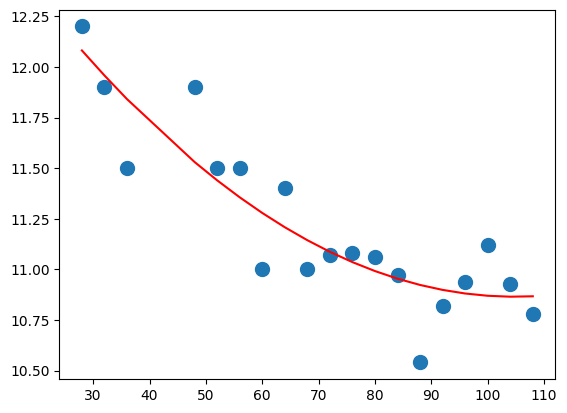

In [8]:
##############################################################################
#              TODO: Calculate the final regression model                    #
##############################################################################
def getPredictions(xlist, coef):
    ylist=[]
    for x in xlist:
        y=0
        for i in range(len(coef)):
            y+=coef[i]*(x**i)
        ylist.append(y)
    return ylist


plt.plot(x, y, 'o', label='Original data', markersize=10)
plt.plot(x, getPredictions(x,getWeights(x,y,2)), 'r', label='Fitted line')
print(polynom(getWeights(x,y,2)))
##############################################################################
#                              END OF YOUR CODE                              #
##############################################################################

## Prediction Using the Best Model

Write a Python program that takes a **year** as input, then outputs the winning women’s Olympic 100-meter **race time** for that year (round to two decimal places). You need to try and print out the results of **2024** and **2028**.

In [9]:
##############################################################################
#         TODO: Predict the race time using the best model                   #
##############################################################################
print("2024 is estimated to be",round(getPredictions([124],getWeights(x,y,2))[0],2),"seconds")
print("2028 is estimated to be",round(getPredictions([128],getWeights(x,y,2))[0],2),"seconds")
##############################################################################
#                              END OF YOUR CODE                              #
##############################################################################

2024 is estimated to be 10.94 seconds
2028 is estimated to be 10.98 seconds


## Prediction Error on 2024

What is the acture of women's 100m final in 2024 Olympics?

Your answer: 10.72

What is the Prediction Error of year 2024?

Your answer:

My prediction was 10.94
prediction error = 10.94 - 10.72 = .22